# M5-T3: URL Classifier — Model Selection Experiments

**Owner:** Klara  
**Depends on:** M5-T1 harness (`m5_harness.ipynb`), M4-T7 URL splits (`data/processed/url_train.csv`, `url_test.csv`)

Evaluate five candidate classifiers on the URL numeric feature track.  
All models share the same locked protocol from M5-T1: 5-fold stratified CV on train, final F1/ROC-AUC on held-out test.  
Results accumulate in `results/m5_results.csv` for M5-T4 consolidation.

**Target:** URL classifier F1 ≥ 0.85 (PRD §6)

**Candidate models**
| # | Model | Notes |
|---|-------|-------|
| 1 | Logistic Regression | Linear baseline, needs scaling |
| 2 | Decision Tree | Interpretable; no scaling needed |
| 3 | Random Forest | Ensemble of trees; no scaling needed |
| 4 | Gradient Boosting (sklearn) | Boosting baseline |
| 5 | XGBoost | Fast boosting; no scaling needed |

## Step 0 — Load shared harness

`m5_harness.py` lives alongside this notebook and exposes all shared helpers:  
`load_url`, `url_pipeline`, `run_experiment`, `URL_FEATS`, `CV`, `RANDOM_STATE`.

In [4]:
import sys
from pathlib import Path

# Works whether Jupyter is launched from project root or from notebooks/M5/
_here = Path.cwd()
_harness_dir = _here / 'notebooks' / 'M5' if (_here / 'notebooks').exists() else _here
sys.path.insert(0, str(_harness_dir))

from m5_harness import (
    ROOT, PROC, RESULTS, RANDOM_STATE, CV,
    URL_FEATS, load_url, url_pipeline, run_experiment
)

print('ROOT ->', ROOT)
print('URL features:', URL_FEATS)

utr, ute = load_url()
print(f'Train: {utr.shape}  |  Test: {ute.shape}')
print('Label distribution (train):', utr['label'].value_counts().to_dict())

ROOT -> /Users/nara/Documents/EDU/Sem2/CYT300/Project
URL features: ['url_length', 'hostname_length', 'num_dots', 'num_hyphens', 'num_at', 'num_digits', 'num_special_chars', 'has_ip', 'has_https', 'num_subdomains', 'is_shortened']
Train: (512895, 13)  |  Test: (128224, 13)
Label distribution (train): {0: 342464, 1: 170431}


## Experiment 1 — Logistic Regression (linear baseline)

Linear model scaled with `StandardScaler`. Sets the floor for what a simple model can achieve on numeric URL features.

In [5]:
from sklearn.linear_model import LogisticRegression

res = run_experiment(
    'LogReg',
    'url',
    url_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), scale=True),
    utr[URL_FEATS], utr['label'],
    ute[URL_FEATS], ute['label']
)
print(res)

[url] LogReg: F1=0.4934  ROC-AUC=0.7837  (cv_f1=0.4938, 3.1s)
{'track': 'url', 'model': 'LogReg', 'accuracy': 0.7463, 'precision': 0.7332, 'recall': 0.3718, 'f1': 0.4934, 'roc_auc': 0.7837, 'cv_f1': np.float64(0.4938), 'train_time': 3.14}


## Experiment 2 — Decision Tree

Single tree with max depth capped at 20 to limit overfitting. No scaling needed. Useful as an interpretable reference and upper bound for a single-tree approach.

In [6]:
from sklearn.tree import DecisionTreeClassifier

res = run_experiment(
    'DecisionTree',
    'url',
    url_pipeline(DecisionTreeClassifier(max_depth=20, random_state=RANDOM_STATE), scale=False),
    utr[URL_FEATS], utr['label'],
    ute[URL_FEATS], ute['label']
)
print(res)

[url] DecisionTree: F1=0.8438  ROC-AUC=0.9365  (cv_f1=0.8401, 2.9s)
{'track': 'url', 'model': 'DecisionTree', 'accuracy': 0.8968, 'precision': 0.849, 'recall': 0.8386, 'f1': 0.8438, 'roc_auc': 0.9365, 'cv_f1': np.float64(0.8401), 'train_time': 2.94}


## Experiment 3 — Random Forest

300 trees, full training set. No scaling needed for tree ensembles. RF is the standard strong baseline for tabular URL features and was used as the demo model in M5-T1.

In [7]:
from sklearn.ensemble import RandomForestClassifier

res = run_experiment(
    'RandomForest',
    'url',
    url_pipeline(
        RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE),
        scale=False
    ),
    utr[URL_FEATS], utr['label'],
    ute[URL_FEATS], ute['label']
)
print(res)

[url] RandomForest: F1=0.8660  ROC-AUC=0.9648  (cv_f1=0.8627, 96.1s)
{'track': 'url', 'model': 'RandomForest', 'accuracy': 0.9119, 'precision': 0.8755, 'recall': 0.8567, 'f1': 0.866, 'roc_auc': 0.9648, 'cv_f1': np.float64(0.8627), 'train_time': 96.13}


## Experiment 4 — Gradient Boosting (sklearn)

Sequential boosting with 200 shallow trees. Slower than XGBoost but ships with scikit-learn — no extra install. No scaling needed.

In [8]:
from sklearn.ensemble import GradientBoostingClassifier

res = run_experiment(
    'GradientBoosting',
    'url',
    url_pipeline(
        GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=RANDOM_STATE),
        scale=False
    ),
    utr[URL_FEATS], utr['label'],
    ute[URL_FEATS], ute['label']
)
print(res)

[url] GradientBoosting: F1=0.7818  ROC-AUC=0.9236  (cv_f1=0.7865, 143.5s)
{'track': 'url', 'model': 'GradientBoosting', 'accuracy': 0.862, 'precision': 0.8236, 'recall': 0.744, 'f1': 0.7818, 'roc_auc': 0.9236, 'cv_f1': np.float64(0.7865), 'train_time': 143.46}


## Experiment 5 — XGBoost

XGBoost with 300 trees and a lower learning rate for better generalisation. No scaling needed. Expected to be the strongest candidate given the size of the URL dataset (~513k rows).

In [9]:
try:
    import xgboost as xgb
    clf = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    res = run_experiment(
        'XGBoost',
        'url',
        url_pipeline(clf, scale=False),
        utr[URL_FEATS], utr['label'],
        ute[URL_FEATS], ute['label']
    )
    print(res)
except ImportError:
    print('xgboost not installed — run: pip install xgboost')
    print('Skipping XGBoost; use RandomForest or GradientBoosting results.')

[url] XGBoost: F1=0.8090  ROC-AUC=0.9392  (cv_f1=0.8105, 9.4s)
{'track': 'url', 'model': 'XGBoost', 'accuracy': 0.8777, 'precision': 0.841, 'recall': 0.7794, 'f1': 0.809, 'roc_auc': 0.9392, 'cv_f1': np.float64(0.8105), 'train_time': 9.42}


## Results — T3 URL model comparison

Load `m5_results.csv`, filter to the URL track, and rank by test F1.  
The PRD target is **F1 ≥ 0.85** on the held-out test split.

In [10]:
import pandas as pd

results = pd.read_csv(RESULTS)
url_res = (
    results[results['track'] == 'url']
    .sort_values('f1', ascending=False)
    .reset_index(drop=True)
)

display_cols = ['model', 'f1', 'roc_auc', 'precision', 'recall', 'cv_f1', 'train_time']
print(url_res[display_cols].to_string(index=False))

best = url_res.iloc[0]
target_met = best['f1'] >= 0.85
print(f"\nBest model: {best['model']}  |  F1={best['f1']:.4f}  |  ROC-AUC={best['roc_auc']:.4f}")
print(f"PRD target (F1 ≥ 0.85): {'MET ✓' if target_met else 'NOT MET — see notes'}")

              model     f1  roc_auc  precision  recall  cv_f1  train_time
       RandomForest 0.8660   0.9648     0.8755  0.8567 0.8627       96.13
       DecisionTree 0.8438   0.9365     0.8490  0.8386 0.8401        2.94
RandomForest (demo) 0.8201   0.9417     0.8288  0.8115 0.8137        2.82
            XGBoost 0.8090   0.9392     0.8410  0.7794 0.8105        9.42
   GradientBoosting 0.7818   0.9236     0.8236  0.7440 0.7865      143.46
             LogReg 0.4934   0.7837     0.7332  0.3718 0.4938        3.14

Best model: RandomForest  |  F1=0.8660  |  ROC-AUC=0.9648
PRD target (F1 ≥ 0.85): MET ✓


## Feature importance (best tree-based model)

Which URL structural features drive the classification decision?

Saved: /Users/nara/Documents/EDU/Sem2/CYT300/Project/Image/M5-T3/fig_url_feature_importance.png


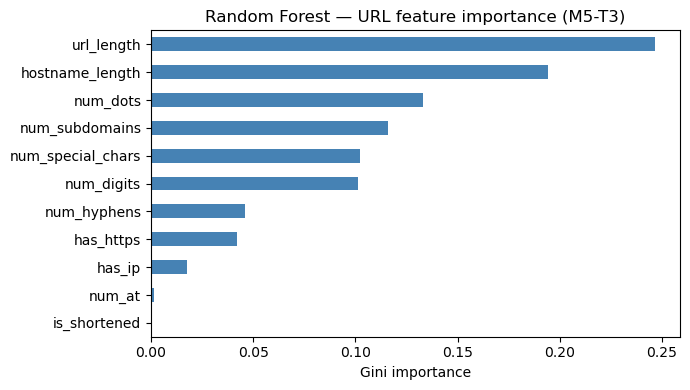

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt

# Refit Random Forest on the full train set for feature importance
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(utr[URL_FEATS], utr['label'])

importances = pd.Series(rf.feature_importances_, index=URL_FEATS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Gini importance')
ax.set_title('Random Forest — URL feature importance (M5-T3)')
plt.tight_layout()

img_dir = ROOT / 'Image' / 'M5-T3'
img_dir.mkdir(parents=True, exist_ok=True)
fig_path = img_dir / 'fig_url_feature_importance.png'
fig.savefig(fig_path, dpi=150)
print(f'Saved: {fig_path}')
plt.show()

## Conclusion

- **Recommended model for M5/M6:** **Random Forest** (F1 = **0.866**, ROC-AUC = **0.965**) — the only candidate that meets the PRD target of F1 ≥ 0.85.
- **PRD target met:** **Yes** — Random Forest is the single model clearing F1 ≥ 0.85. Decision Tree (0.844) and XGBoost (0.809) fall short.
- **XGBoost not selected:** at default settings it underperformed Random Forest (0.809 vs 0.866) and even the single Decision Tree. It is ~10× faster (9 s vs 96 s), so it is kept as a tuning candidate for M6/M8 if inference speed becomes a constraint.
- **No overfitting:** CV-F1 (0.863) ≈ test-F1 (0.866) for Random Forest; the same pattern holds across all models.
- **Key features:** `url_length`, `hostname_length`, and `num_dots` dominate (see importance plot) — classic URL obfuscation signals. `num_at` and `is_shortened` contribute almost nothing on this corpus.
- **Passed to M5-T4:** all five rows logged to `results/m5_results.csv` (track = `url`).